# 06. Локальная ценовая эластичность

Калиброванная модель из `05_training` → эластичность на **test**-выборке (rolling-snapshot,
тот же риск-сет, что в 05; для эластичности берём по одному последнему снапшоту на лот —
чистый кросс-срез активных лотов).


In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import (
    MODEL_DATASET_PARQUET, CALIBRATED_MODEL_PATH, PROCESSED_DIR,
    ELAST_CSV, TARGET_COL, PRICE_COL,
)
from src.modeling import CalibratedModel  # noqa: F401 — для joblib.load

C1, C2 = "#2C7BB6", "#D7542B"
plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.right": False, "axes.spines.top": False})
FIG_DIR = REPO_ROOT / "reports" / "figures" / "06_elasticity"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DELTA = 0.01                              # +1% для точечной эластичности
TEST_FROM = "2024-10-01"                  # тест-окно как в 05
HORIZON_CUT = pd.Timestamp("2025-04-30")  # right-censoring как в 05
MULT = [-0.10, -0.05, 0.0, 0.05, 0.10]    # сетка мультипликаторов цены (кривая/монотонность)

## 1. Модель и test-выборка

In [2]:
model: CalibratedModel = joblib.load(CALIBRATED_MODEL_PATH)
FEATURES = model.features
CAT_FEATURES = model.cat_features
print(f"Модель: {CALIBRATED_MODEL_PATH.name}  |  признаков: {len(FEATURES)} ({len(CAT_FEATURES)} кат.)")

df = pd.read_parquet(MODEL_DATASET_PARQUET)
# тот же риск-сет, что в 05: дроп post-sale + right-censoring; затем тест-окно
data = df[(df["is_sold_past"] == 0) & (df["file_date"] <= HORIZON_CUT)]
test = data[data["file_date"] >= TEST_FROM].copy()
# для эластичности — один (последний) снапшот на лот: чистый кросс-срез активных лотов
test = test.sort_values(["unit_match_key", "file_date"]).drop_duplicates("unit_match_key", keep="last")

print(f"test: {len(test):,} лотов  ({test['file_date'].min().date()} … {test['file_date'].max().date()})")
print(f"P({TARGET_COL}): {100 * test[TARGET_COL].mean():.2f}%")
print("unit_status:", test["unit_status"].value_counts().to_dict())

Модель: catboost_sale_prob_calibrated.pkl  |  признаков: 102 (13 кат.)
test: 209,904 лотов  (2024-10-02 … 2025-04-02)
P(is_sold_next_month): 6.09%
unit_status: {'обрыв без сделки': 95187, 'цензурирован': 89052, 'продан': 25665}


## 2. Шок цены и эластичность

`apply_price_shock` — per-lot deviation. `segment_demand_elasticity` —
area-взвешенная эластичность ожидаемого m²-спроса (тождество `E_g=Σwᵢ·Eᵢ`, `wᵢ=pᵢ·areaᵢ/Σ`),
а не простое среднее локальных ε.

In [3]:
# шок уровня цены (src.elasticity): двигаются price, log_price, discount_abs, rel_price;
# price_change_*, rel_price_district, price_gap_to_p10 заморожены. price_rank_seg тоже
# заморожен (seg_cols не передаём — на полном test срезы смешаны).
from src.elasticity import apply_price_shock


def p_sale(model, X):
    return model.predict_proba(X[FEATURES])[:, 1]


def point_elasticity(model, X, delta=DELTA):
    """d log P(sale) / d log price для каждого лота. Возвращает (Series ε, p0)."""
    p0 = p_sale(model, X)
    p1 = p_sale(model, apply_price_shock(X, delta))
    with np.errstate(divide="ignore", invalid="ignore"):
        e = np.where(p0 > 1e-8, (p1 - p0) / (p0 * delta), np.nan)
    return pd.Series(e, index=X.index, name="elasticity"), p0


def segment_demand_elasticity(model, d, group_cols, *, delta=DELTA, min_n=30):
    """(а) area-взвешенная сегментная ε: E_g = (Q1-Q0)/(Q0·Δ), Q = Σ p·area."""
    X = d[FEATURES]
    p0 = p_sale(model, X)
    p1 = p_sale(model, apply_price_shock(X, delta))
    a = d["area"].to_numpy()
    t = d[group_cols].copy()
    t["q0"], t["q1"] = p0 * a, p1 * a
    g = (t.groupby(group_cols, observed=True)
           .agg(q0=("q0", "sum"), q1=("q1", "sum"), n=("q0", "size"))
           .reset_index())
    g["elasticity"] = (g["q1"] - g["q0"]) / (g["q0"] * delta)
    return g[g["n"] >= min_n].sort_values("elasticity")


def headline_demand_e(d, delta=DELTA):
    """Одно число — area-взвешенная ε по всей подвыборке."""
    X = d[FEATURES]
    p0 = p_sale(model, X)
    p1 = p_sale(model, apply_price_shock(X, delta))
    a = d["area"].to_numpy()
    Q0, Q1 = (p0 * a).sum(), (p1 * a).sum()
    return (Q1 - Q0) / (Q0 * delta)

Точек: 167,858  (NaN: 42,046)
Медиана ε: 0.0000  |  среднее: -0.7483
5–95 пц: -3.749 … 0.000
Доля ε>0 (контр-интуитивных, цена↑→P↑): 0.5%


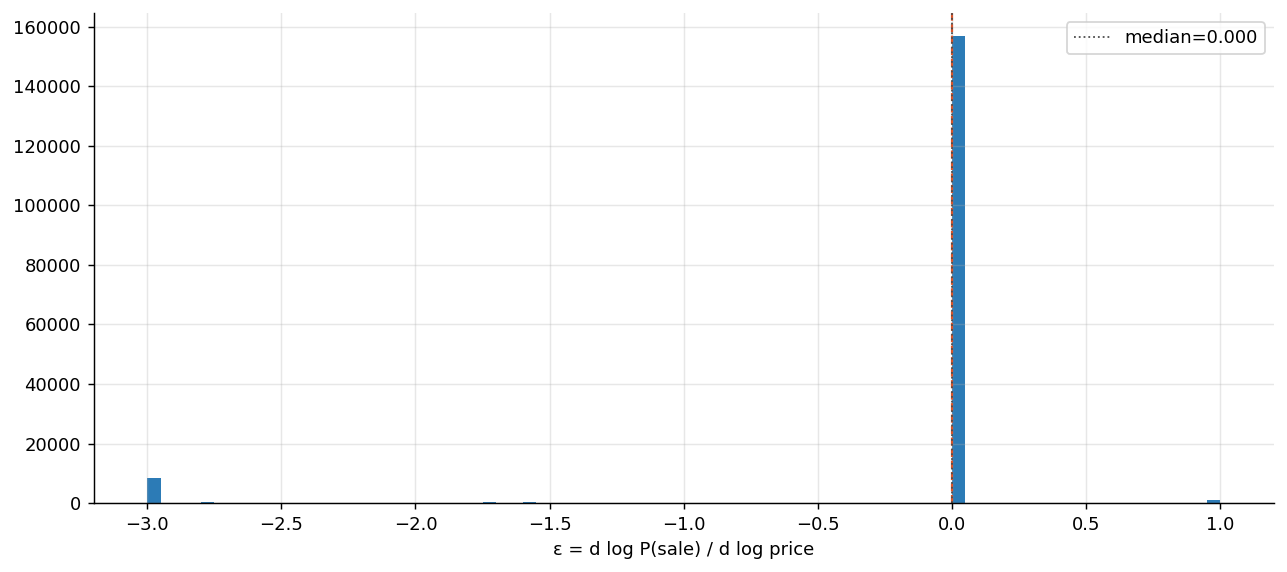

In [4]:
elast, p0 = point_elasticity(model, test[FEATURES])
test = test.assign(elasticity=elast.values, p_sale=p0)

valid = elast.dropna()
print(f"Точек: {len(valid):,}  (NaN: {elast.isna().sum():,})")
print(f"Медиана ε: {valid.median():.4f}  |  среднее: {valid.mean():.4f}")
print(f"5–95 пц: {valid.quantile(0.05):.3f} … {valid.quantile(0.95):.3f}")
print(f"Доля ε>0 (контр-интуитивных, цена↑→P↑): {100*(valid>0).mean():.1f}%")

fig, ax = plt.subplots(figsize=(10, 4.5))
valid.clip(-3, 1).hist(bins=80, ax=ax, color=C1, edgecolor="none")
ax.axvline(0, color=C2, lw=1.2, ls="--")
ax.axvline(valid.median(), color="0.3", lw=1, ls=":", label=f"median={valid.median():.3f}")
ax.set_xlabel("ε = d log P(sale) / d log price"); ax.legend()
plt.tight_layout(); fig.savefig(FIG_DIR / "fig01_elasticity_distribution.png", bbox_inches="tight"); plt.show()

## Контроль монотонности P(sale)

P(sale) должна **не возрастать** с ценой. Скорим test на сетке мультипликаторов и считаем
долю лотов, где вероятность где-то растёт при росте цены. Если нарушений много или знак
медианной ε неверный — нужен `monotone_constraints` на `price`/`rel_price` в 05 + retrain.

средняя P(sale) по мультипликаторам цены:
  -10%: 0.0267
  -5%: 0.0258
  +0%: 0.0249
  +5%: 0.0241
  +10%: 0.0235

агрегатная кривая убывает по цене: True
доля лотов с ε>0 (неверный знак):  0.5%
лот-уровневая немонотонность:      3.9%

✓ GATE (направление): ожидаемый спрос убывает с ценой, знак верный.


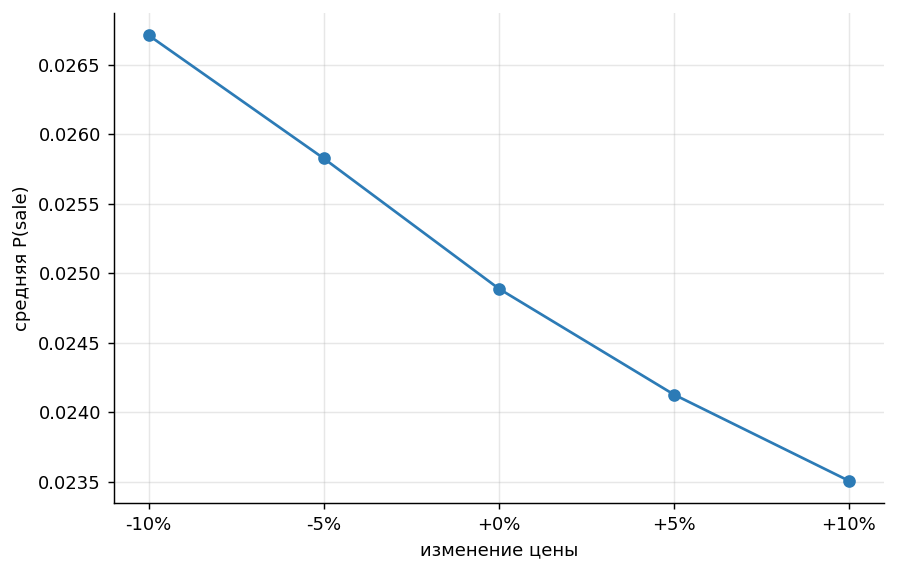

In [5]:
P = np.column_stack([p_sale(model, apply_price_shock(test[FEATURES], m)) for m in MULT])
viol = (np.diff(P, axis=1) > 1e-6).any(axis=1)     # где-то P растёт при росте цены (лот-уровень)
mean_curve = P.mean(axis=0)
share_wrong = float((elast.dropna() > 0).mean())   # доля лотов с неверным знаком ε

print("средняя P(sale) по мультипликаторам цены:")
for m, p in zip(MULT, mean_curve):
    print(f"  {m:+.0%}: {p:.4f}")

# направленный GATE: агрегатная кривая спроса должна убывать, знак ε в основном верный.
# (медиана ε=0 у tree-модели при δ=1% — норма: цена не пересекает сплит; на медиану НЕ опираемся.)
agg_monotone = bool(np.all(np.diff(mean_curve) < 0))
gate_ok = agg_monotone and share_wrong < 0.10
print(f"\nагрегатная кривая убывает по цене: {agg_monotone}")
print(f"доля лотов с ε>0 (неверный знак):  {100*share_wrong:.1f}%")
print(f"лот-уровневая немонотонность:      {100*viol.mean():.1f}%")
print("\n" + ("✓ GATE (направление): ожидаемый спрос убывает с ценой, знак верный."
               if gate_ok else
               "⚠️ GATE: неверное направление агрегатного спроса — модель непригодна для эластичности."))
if viol.mean() > 0.15:
    print(f"ℹ️  {100*viol.mean():.0f}% лотов локально немонотонны (tree-эффект при малом δ). "
          "Для ГЛАДКИХ полотных кривых в дашборде → monotone_constraints на "
          "price/log_price/rel_price в 05 + retrain.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot([f"{m:+.0%}" for m in MULT], mean_curve, "o-", color=C1)
ax.set_xlabel("изменение цены"); ax.set_ylabel("средняя P(sale)")
plt.tight_layout(); fig.savefig(FIG_DIR / "fig02_monotonicity_curve.png", bbox_inches="tight"); plt.show()

## Обрыв без сделки

62% датасета — «обрыв без сделки» (таргет=0). Значит `P(sold)` модели — это «продастся ИЛИ
исчезнет из наблюдения», а ε — реакция на (продажу ИЛИ делистинг). Сравниваем headline-ε на
всём test и без «обрыва»; смотрим corr(обрыв, rel_price).

In [6]:
by = (test.groupby("unit_status", observed=True)
          .agg(n=("elasticity", "size"), mean_p=("p_sale", "mean"),
               mean_e=("elasticity", "mean"), median_e=("elasticity", "median"))
          .reset_index())
display(by)

e_full = headline_demand_e(test)
e_no_churn = headline_demand_e(test[test["unit_status"] != "обрыв без сделки"])
print(f"area-взвеш. ε (весь test):     {e_full:.4f}")
print(f"area-взвеш. ε (без «обрыва»):  {e_no_churn:.4f}")
print(f"расхождение: {100*(e_no_churn-e_full)/abs(e_full):.0f}%  (большое → withdrawal доминирует)")

churn = (test["unit_status"] == "обрыв без сделки").astype(int).to_numpy()
rp = test["rel_price"].fillna(test["rel_price"].median()).to_numpy()
print(f"corr(обрыв, rel_price): {np.corrcoef(churn, rp)[0,1]:.3f}")

,unit_status,n,mean_p,mean_e,median_e
0,обрыв без сделки,95187,0.020591,-0.771959,0.0
1,продан,25665,0.062013,-0.563594,0.0
2,цензурирован,89052,0.018788,-0.791536,0.0


area-взвеш. ε (весь test):     -0.7035
area-взвеш. ε (без «обрыва»):  -0.6780
расхождение: 4%  (большое → withdrawal доминирует)
corr(обрыв, rel_price): -0.006


## 3. Агрегация по сегментам

In [7]:
GROUP_COLS = ["region", "project_class", "room_count"]
seg = segment_demand_elasticity(model, test, GROUP_COLS)
print(f"Сегментов (n≥30): {len(seg)}")
display(seg.head(8)); display(seg.tail(8))

Сегментов (n≥30): 21


,region,project_class,room_count,q0,q1,n,elasticity
4,Москва,бизнес,5,3.623536,3.068649,64,-15.313397
13,Московская область,бизнес,4,58.988825,56.554491,61,-4.126771
12,Московская область,бизнес,3,152.509556,149.707576,167,-1.837249
10,Московская область,бизнес,1,77.085466,75.744064,118,-1.740149
17,Московская область,комфорт,4,460.385601,453.639933,606,-1.465221
21,Новая Москва,комфорт,2,8651.515171,8563.827628,10343,-1.013551
7,Москва,комфорт,2,16680.984436,16516.307827,13064,-0.987212
22,Новая Москва,комфорт,3,4391.701981,4348.654810,4764,-0.980193


,region,project_class,room_count,q0,q1,n,elasticity
20,Новая Москва,комфорт,1,15006.301416,14911.053040,16051,-0.634723
1,Москва,бизнес,2,9926.741647,9866.526626,17036,-0.606594
0,Москва,бизнес,1,10143.348550,10084.824423,20682,-0.576970
16,Московская область,комфорт,3,17423.378127,17330.486518,9100,-0.533144
2,Москва,бизнес,3,5593.064977,5563.482340,8725,-0.528916
23,Новая Москва,комфорт,4,88.304278,87.966144,1068,-0.382919
11,Московская область,бизнес,2,61.401447,61.176617,191,-0.366164
9,Москва,комфорт,4,306.647079,306.155964,421,-0.160157


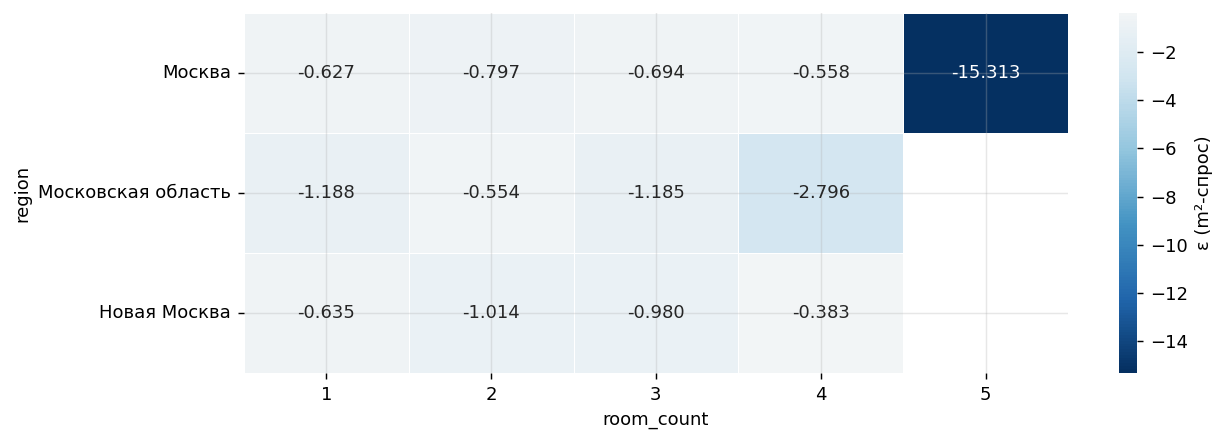

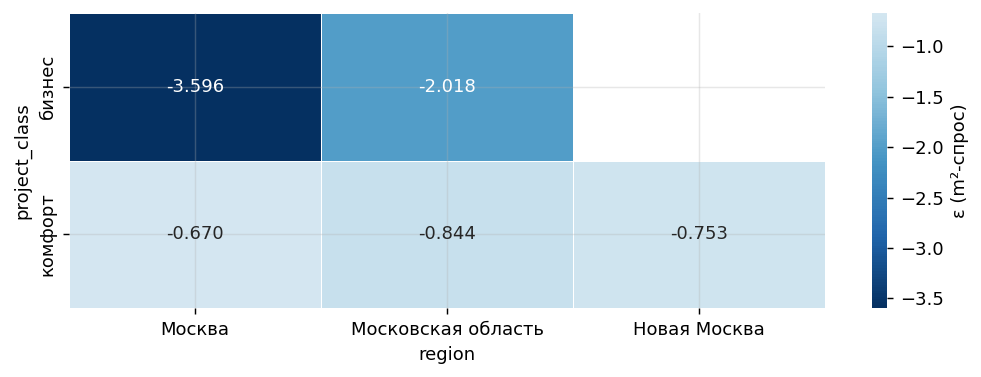

In [8]:
pivot = seg.pivot_table(index="region", columns="room_count", values="elasticity", aggfunc="mean")
if not pivot.empty:
    fig, ax = plt.subplots(figsize=(10, max(3.5, len(pivot) * 0.55)))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0, linewidths=0.3,
                ax=ax, cbar_kws={"label": "ε (m²-спрос)"})
    plt.tight_layout(); fig.savefig(FIG_DIR / "fig03_heatmap_region_room.png", bbox_inches="tight"); plt.show()

pivot2 = seg.pivot_table(index="project_class", columns="region", values="elasticity", aggfunc="mean")
if not pivot2.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(pivot2) * 0.6)))
    sns.heatmap(pivot2, annot=True, fmt=".3f", cmap="RdBu_r", center=0, linewidths=0.3,
                ax=ax, cbar_kws={"label": "ε (m²-спрос)"})
    plt.tight_layout(); fig.savefig(FIG_DIR / "fig04_heatmap_class_region.png", bbox_inches="tight"); plt.show()

## 4. Эластичность vs относительная цена

,mean,median,count
rel_price_bin,,,
"(0.342, 0.836]",0.019181,0.0,16786
"(0.836, 0.895]",-0.378232,0.0,16787
"(0.895, 0.933]",-1.328106,0.0,16785
"(0.933, 0.965]",-1.405915,0.0,16785
"(0.965, 0.992]",-2.989260,0.0,16787
"(0.992, 1.013]",-0.866263,0.0,16785
"(1.013, 1.048]",0.060912,0.0,16785
"(1.048, 1.099]",-0.296865,0.0,16786
"(1.099, 1.189]",-0.105930,0.0,16786


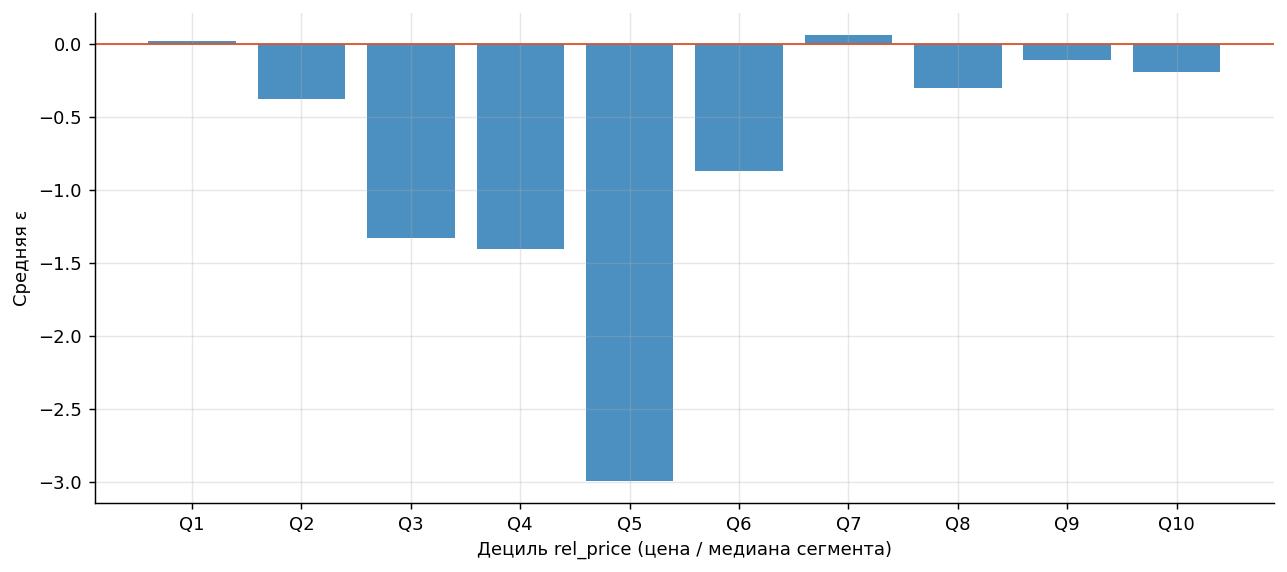

In [9]:
plot_df = test.dropna(subset=["elasticity", "rel_price"]).copy()
plot_df["rel_price_bin"] = pd.qcut(plot_df["rel_price"], q=10, duplicates="drop")
by_bin = plot_df.groupby("rel_price_bin", observed=True)["elasticity"].agg(["mean", "median", "count"])
display(by_bin)

fig, ax = plt.subplots(figsize=(10, 4.5))
xs = range(len(by_bin))
ax.bar(xs, by_bin["mean"], color=C1, alpha=0.85)
ax.axhline(0, color=C2, lw=1)
ax.set_xticks(list(xs)); ax.set_xticklabels([f"Q{i+1}" for i in xs])
ax.set_xlabel("Дециль rel_price (цена / медиана сегмента)"); ax.set_ylabel("Средняя ε")
plt.tight_layout(); fig.savefig(FIG_DIR / "fig05_elasticity_by_rel_price.png", bbox_inches="tight"); plt.show()

## 4b. Форма спроса: факт vs модель по rel_price (асимметрия)

Главный содержательный результат: спрос **эластичен ниже медианы сегмента и почти плоский выше**.
Фактическая доля продаж падает от ~15% (дёшево) до ~5% у медианы и дальше держится ~5%.

,rp_bin,rel_price,actual,model,n
0,"(0.309, 0.843]",0.7768,0.1256,0.0442,20991
1,"(0.843, 0.903]",0.8762,0.0826,0.0332,20990
2,"(0.903, 0.942]",0.9237,0.0666,0.0282,20990
3,"(0.942, 0.973]",0.9577,0.0596,0.0236,20991
4,"(0.973, 0.997]",0.9855,0.0482,0.0208,20990
5,"(0.997, 1.017]",1.0056,0.0427,0.0171,20998
6,"(1.017, 1.051]",1.0333,0.0442,0.0200,20984
7,"(1.051, 1.104]",1.0750,0.0454,0.0211,20989
8,"(1.104, 1.196]",1.1438,0.0482,0.0214,20990
9,"(1.196, 4.8]",1.3433,0.0456,0.0194,20991


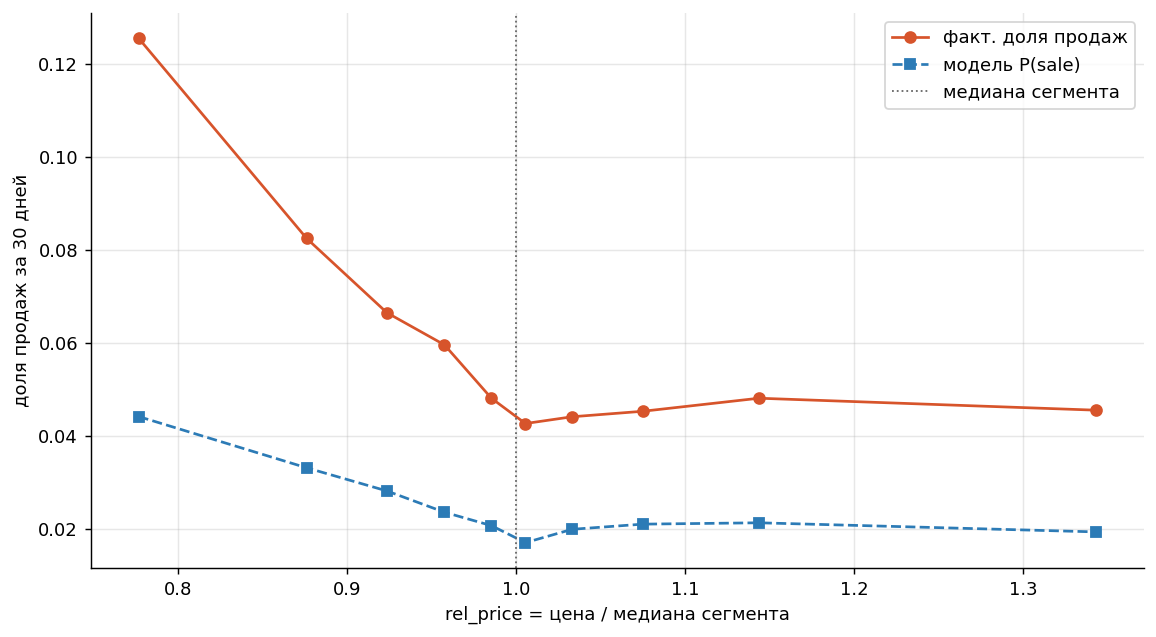

In [10]:
# ФАКТ доля продаж vs модель p_sale по децилю rel_price — асимметрия спроса
dd = test.dropna(subset=["rel_price"]).copy()
dd["rp_bin"] = pd.qcut(dd["rel_price"], 10, duplicates="drop")
curve = (dd.groupby("rp_bin", observed=True)
           .agg(rel_price=("rel_price", "mean"), actual=(TARGET_COL, "mean"),
                model=("p_sale", "mean"), n=(TARGET_COL, "size"))
           .reset_index())
display(curve.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve["rel_price"], curve["actual"], "o-", color=C2, label="факт. доля продаж")
ax.plot(curve["rel_price"], curve["model"], "s--", color=C1, label="модель P(sale)")
ax.axvline(1.0, color="0.4", lw=1, ls=":", label="медиана сегмента")
ax.set_xlabel("rel_price = цена / медиана сегмента")
ax.set_ylabel("доля продаж за 30 дней")
ax.legend()
plt.tight_layout(); fig.savefig(FIG_DIR / "fig06_demand_shape_asymmetry.png", bbox_inches="tight"); plt.show()

## 5. Сохранение

In [11]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
seg.drop(columns=["q0", "q1"]).to_csv(ELAST_CSV, index=False)
print(f"Сохранено: {ELAST_CSV}  ({len(seg)} сегментов)")

point_path = PROCESSED_DIR / "elasticity_point_test.parquet"
test[["unit_match_key", "file_date", "region", "project_class", "room_count", "unit_status",
      "area", "price", "rel_price", "p_sale", "elasticity", TARGET_COL]].to_parquet(point_path, index=False)
print(f"Точечная эластичность: {point_path.name}  ({len(test):,} лотов)")

Сохранено: /Users/adesayan/demand_elasticity/data/processed/elasticity_by_segment.csv  (21 сегментов)
Точечная эластичность: elasticity_point_test.parquet  (209,904 лотов)
